# Types of Data


*   Structured Data, e.g., relational databases (data stored in tables)
*   Semi-structured Data, e.g., emails (containing some structure such as sender and subject, but differing in the content and format)
*   Unstructured Data, e.g., text files (no clear structure)


# Using PANDAS
(Subtitle: chew your data)

`pandas` is a very popular python library, specialized in handling spreadsheet data. Like a true panda, it handles data by chewing it relentlessly and effortlessly.

The name comes from **PAN**el **DA**ta**S**, not from <img src="https://cdn.onlinewebfonts.com/svg/img_136825.png" alt="block-01" border="" width=50>.


Interesting links:
* Official Documentation: [Starter Guide](https://pandas.pydata.org/docs/getting_started/index.html#getting-started)
* Official Documentation: [User Guide](https://pandas.pydata.org/docs/user_guide/index.html#user-guide), [10 mins to pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
* Official Documentation: [API Reference](https://pandas.pydata.org/docs/reference/index.html#api) (*you don't want to read this*)
* Tutorial: [Pandas for Beginners](https://dev.to/thepythongeeks/python-pandas-for-beginners-a-complete-guide-part-1-51pm) A string of blog posts
* Tutorial: [Pandas Introduction](https://www.youtube.com/watch?v=PfVxFV1ZPnk) Youtube video
* Full Class: [FreeCodeCamp](https://www.youtube.com/watch?v=r-uOLxNrNk8) 6 hours of lecture + exercise notebooks
* **Many more**: Head to your Search Engine, and search for `python pandas beginner` in your mother tongue


In [1]:
import pandas as pd

# Pandas data structures: *Series* vs *Dataframes*

Series: 1-d array with labels (index)

Dataframe: 2-d array with labels (index, columns)

---



# Example (Chipotle)

**Acknowledgements**

The Chipotle dataset is used courtesy of Kevin Markham, who made it available publicly.

It is part of a course of Data Analytics.

See [this link](https://github.com/justmarkham/DAT8) to the original material.


---


**Your Mission**

You are a restaurant's manager. This dataset is an extract generated by the software of your cash register. It tracks all the orders made by your customers during a shift.

As a manager, your questions are:
* Show me the distribution of revenue per menu item

<img src="https://i.postimg.cc/W4D9D4Zd/kn-pandas-revenue-per-item.png" border="0" width=400>

* Show me the average order value, and min/max
```
mean       18.811429
min        10.080000
max       205.250000
```

* Show me the distribution of order value

<img src="https://i.postimg.cc/t44vjkCt/kn-pandas-order-value-dsitribution.png" border="0" width=400>






---


**Vocabulary**

* **Order**: this is one complete order from a customer, made of different items from the menu. Each order is identified by its `order_id`
* **Itemized order**: this is the list of individual items ordered in a single customer order. All rows of an itemized order share the same `order_id`

## Import data

Download data from a file. In this case, we use a text file, where each line is a row of our spreadsheet, and columns are separated by tabulation character `'\t'`.

Pandas include many data readers, so you can import Excel spreadsheets, from a database query, etc...

`pd.read_csv()` is the function `read_csv()` from the module `pd`, which is the nickname we gave to `pandas`

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv', sep='\t')

## First look

* `df` is an object
* its class is `DataFrame`.
* `df.head()` is a call to the method `head()` of object `df`
* This method display the first N rows of the spreadsheet
* NB: `df` has 360 methods you can call...
* `df` has 5 columns, named `order_id`, `quantity`, `item_name`, `choice_description`, `item_price`
* On the left, the **index** of rows, in this case it is zero-based

Check the functions available in a panda dataframe https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.barh.html

In [3]:
df.head(6)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98


* `dtypes` is an attribute of the object `df`, it is a value
* It indicates the type of data in each column
* `object` indicates something else than a number
* in our case, `item_price` is a string like `'$2.39'`

In [4]:
df.dtypes

order_id               int64
quantity               int64
item_name             object
choice_description    object
item_price            object
dtype: object

* `df['item_name']` gives you the content of the column `item_name` (*as an object of class pd.Series, therefore the different display)*
* `df[['order_id, 'item_name']]` gives the contents of 2 columns `order_id, item_name` (*as an object of class pd.DataFrame*)

In [5]:
# Just one column
col_item_name = df['item_name']
print(col_item_name.head(3), type(col_item_name))

0    Chips and Fresh Tomato Salsa
1                            Izze
2                Nantucket Nectar
Name: item_name, dtype: object <class 'pandas.core.series.Series'>


In [6]:
# Using a LIST of column names
two_col = df[['order_id', 'item_name']]
print(two_col.head(3), type(two_col))

   order_id                     item_name
0         1  Chips and Fresh Tomato Salsa
1         1                          Izze
2         1              Nantucket Nectar <class 'pandas.core.frame.DataFrame'>


List all orders of `'Izze'`
* `df[condition]` shows only rows where the condition is True
* a condition is something like `df['item_name'] == 'Izze'`: it is true for rows where the value in colums `item_name` is equal to the string `'Izze'`


In [7]:
# all the rows where item_name is equal to Izze

df[df['item_name'] == 'Izze']


,order_id,quantity,item_name,choice_description,item_price
1,1,1,Izze,[Clementine],$3.39
24,12,1,Izze,[Grapefruit],$3.39
47,21,1,Izze,[Blackberry],$3.39
66,30,1,Izze,[Blackberry],$3.39
359,155,1,Izze,[Blackberry],$3.39
360,155,1,Izze,[Grapefruit],$3.39
430,186,1,Izze,[Grapefruit],$3.39
579,237,1,Izze,[Clementine],$3.39
580,237,1,Izze,[Grapefruit],$3.39
1059,436,1,Izze,[Clementine],$3.39


## Transform Data

* `item_price` is a text, we would prefer to have numbers, so we can add them.
* `convert_price_string_to_float` is a function we create, it has one argument: a text, it converts into `float` the text after the first character (list slice)
* `txt = '$2.39'` then `txt[1:] = '2.39'`, then `float('2.39') = 2.39`
* `df['item_price']` is the column `item_price` of the spreadsheet
* the method `apply` applies a function to each element of this column
* the results are overwriting the current data in the column `df['item_price']`

In [8]:
txt = "01234"
print(txt[1:3])

12


In [10]:
print(txt[-5:-2:2])

02


In [11]:
df['item_price'].head(3)

0    $2.39 
1    $3.39 
2    $3.39 
Name: item_price, dtype: object

In [12]:
def convert_price_string_to_float(txt):  
    return float(txt[1:])

df['item_price'] = df['item_price'].apply(convert_price_string_to_float)

In [13]:
df['item_price'].head(3)

0    2.39
1    3.39
2    3.39
Name: item_price, dtype: float64

In [14]:
df.dtypes

order_id                int64
quantity                int64
item_name              object
choice_description     object
item_price            float64
dtype: object

* In each itemized order we have the price of items, and the quantity on the order
* The unit price for this item is the division `item_price` / `quantity`
* With Pandas, we write exactly this product into our code
* `df['unit_item_price'] = ...` creates a new column `total_for_item`
* this new column has the same number of rows as `df`
* each element is the division of `item_price` by `quantity` on the same row

In [15]:
df['unit_item_price'] = df['item_price'] / df['quantity']
df.head()

,order_id,quantity,item_name,choice_description,item_price,unit_item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39,2.39
1,1,1,Izze,[Clementine],3.39,3.39
2,1,1,Nantucket Nectar,[Apple],3.39,3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,2.39,2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98,8.49


In [16]:
df.dtypes

order_id                int64
quantity                int64
item_name              object
choice_description     object
item_price            float64
unit_item_price       float64
dtype: object

## Aggregate and Visualize

### Total Revenue

In [17]:
df['item_price'].sum()

np.float64(34500.16)

### Revenue per Item

* `groupby` is a method of `df`
* groups all rows with the same `item_name`
* `df.groupby('item_name')` is an object, of class `pd.DataFrameGroupBy`. It has 134 methods.
* `sum` is a method of `df.groupby('item_name')`
* What it does is:
   * rows are grouped by `item_name`
   * it is a new spreadsheet with the same columns
   * one row per `item_name` value
   * for each column it aggregates the value, using `sum()` = sums all values
   * in the row with `item_name = 'Chicken Bowl'`, at column `item_price` we read the sum of all `item_price` when the item had the name `Chicken Bowl`, so we have the total revenue for this item `Chicken Bowl` throughout all the orders
* `['item_price']` selects only the column `item_price` of the new spreadsheet.
* On this new spreadsheet with 1 column (it is `pd.Series` object), we use the method `sort_values` to sort the rows according to the values in the only column

In [18]:
df[df['item_name'] == 'Chicken Bowl']['item_price'].sum()  ## alternatively?

np.float64(7342.7300000000005)

In [19]:
df['item_price'][df['item_name'] == 'Chicken Bowl'].sum()

np.float64(7342.7300000000005)

In [20]:
df.head(3)

,order_id,quantity,item_name,choice_description,item_price,unit_item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39,2.39
1,1,1,Izze,[Clementine],3.39,3.39
2,1,1,Nantucket Nectar,[Apple],3.39,3.39


In [21]:
df[df['item_name'] == 'Chicken Bowl'].head(3)

,order_id,quantity,item_name,choice_description,item_price,unit_item_price
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98,8.49
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",10.98,10.98
13,7,1,Chicken Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Rice,...",11.25,11.25


In [22]:
df.groupby('item_name')['item_price'].sum()

item_name
6 Pack Soft Drink                         356.95
Barbacoa Bowl                             672.36
Barbacoa Burrito                          894.75
Barbacoa Crispy Tacos                     120.21
Barbacoa Salad Bowl                       106.40
Barbacoa Soft Tacos                       250.46
Bottled Water                             302.56
Bowl                                       29.60
Burrito                                    44.40
Canned Soda                               137.34
Canned Soft Drink                         438.75
Carnitas Bowl                             736.71
Carnitas Burrito                          597.83
Carnitas Crispy Tacos                      77.96
Carnitas Salad                              8.99
Carnitas Salad Bowl                        66.34
Carnitas Soft Tacos                       375.94
Chicken Bowl                             7342.73
Chicken Burrito                          5575.82
Chicken Crispy Tacos                      472.13
Chicken Sa

In [23]:
by_item_name = df.groupby('item_name')['item_price'].sum().sort_values(ascending=False)   ## alternatively?
by_item_name.head(3)

item_name
Chicken Bowl       7342.73
Chicken Burrito    5575.82
Steak Burrito      3851.43
Name: item_price, dtype: float64

In [24]:
by_item_name = df.groupby('item_name').sum()['item_price'].sort_values(ascending=False) 
by_item_name.head(3)

item_name
Chicken Bowl       7342.73
Chicken Burrito    5575.82
Steak Burrito      3851.43
Name: item_price, dtype: float64

<Axes: ylabel='item_name'>

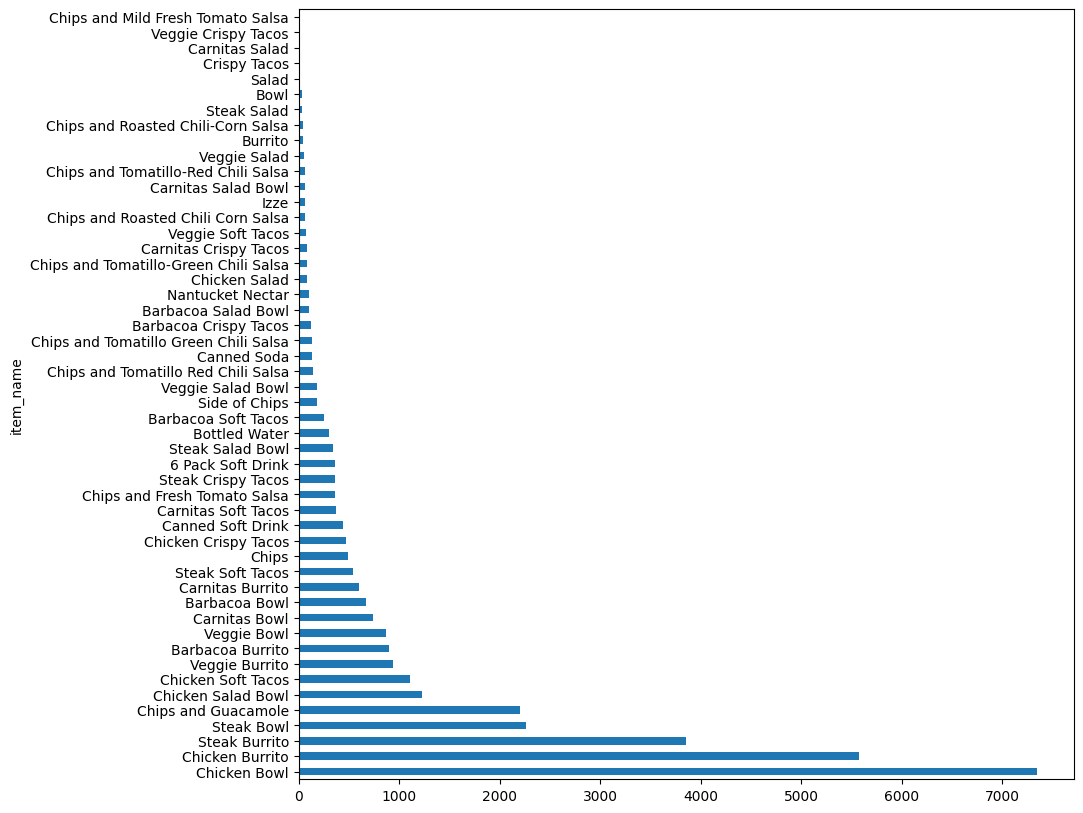

In [25]:
by_item_name.plot.barh(figsize=(10,10))

* `_ = ` gets rid of the display `<matplotlib.axes._subplots.AxesSubplot at 0x7f543bbcdc18>`


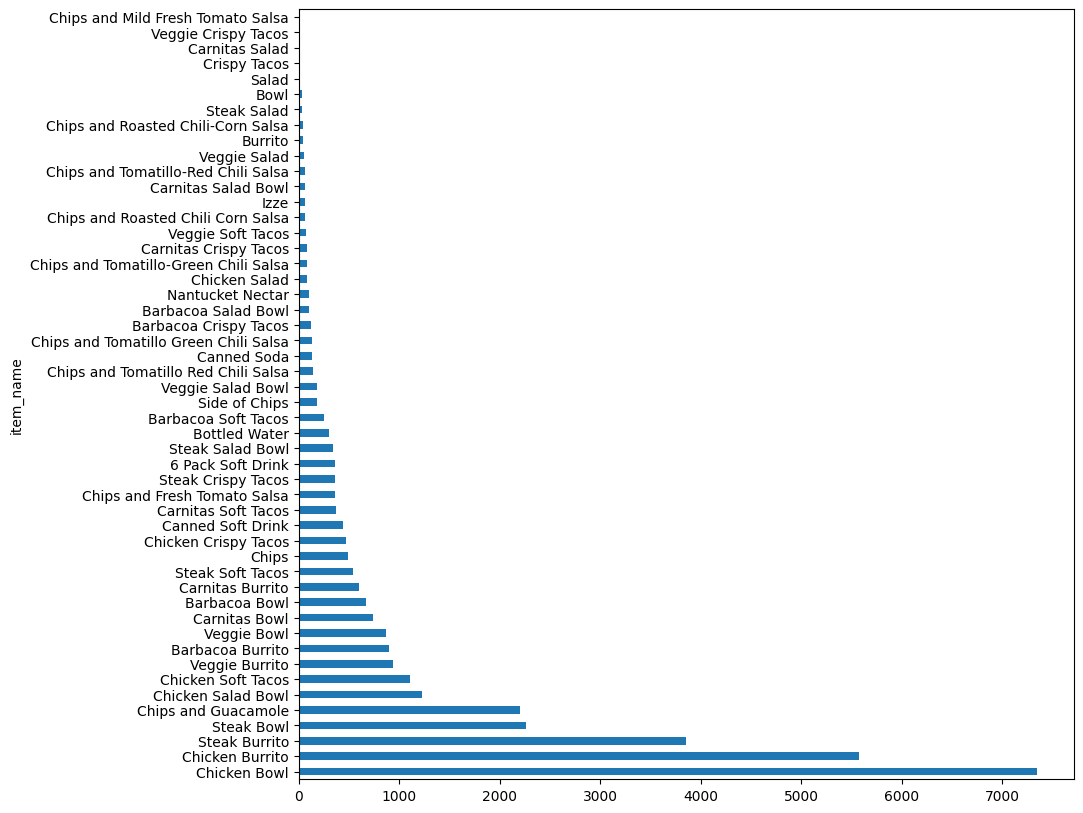

In [26]:
_ = by_item_name.plot.barh(figsize=(10,10))

## save the plot to a file
import matplotlib.pyplot as plt
plt.savefig('Revenue per Item.png', bbox_inches='tight', dpi=300)

### Revenue per Order

What is the distribution of the basket value?

In [27]:
df[df['order_id'] == 1]

,order_id,quantity,item_name,choice_description,item_price,unit_item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39,2.39
1,1,1,Izze,[Clementine],3.39,3.39
2,1,1,Nantucket Nectar,[Apple],3.39,3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,2.39,2.39


For order 1, we expect a total basket value of 2.39 + 3.39 + 3.39 + 2.39 = 11.56

In [28]:
by_order = df.groupby('order_id')['item_price'].sum()  ## revenue per order
by_order.head()

order_id
1    11.56
2    16.98
3    12.67
4    21.00
5    13.70
Name: item_price, dtype: float64

* `describe` is a method of the object `by_order`
* it gives you basic statistics, per column

In [29]:
by_order.describe(percentiles=[.99])  ## without percentiles=[.99]?

count    1834.000000
mean       18.811429
std        11.652512
min        10.080000
50%        16.200000
99%        64.140500
max       205.250000
Name: item_price, dtype: float64

* `by_order` is a spreadsheet with 1 column
* `by_order[by_order < 50]` is a spreadsheet with 1 column, with only the rows where the value in the only column are strictly less than `50`
* we filter to see only the orders of less than `50$`, as there are few big orders that will complicate the visualization

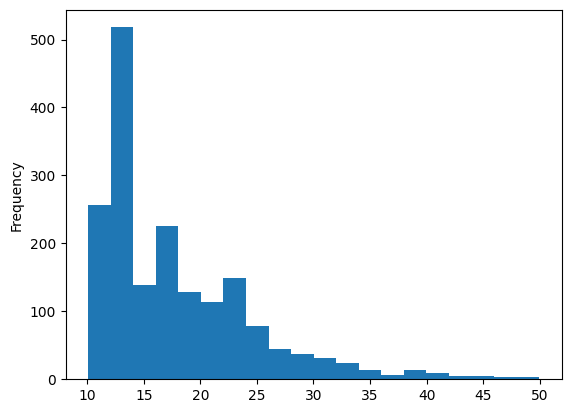

In [30]:
_ = by_order[by_order < 50].plot.hist(bins=20)

* Many visualizations are possible
* Kernel Density Estimate (KDE) plot shows a smooth curve representing the distribution

c:\Users\orrru\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\plotting\_matplotlib\hist.py:276: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.stats import gaussian_kde


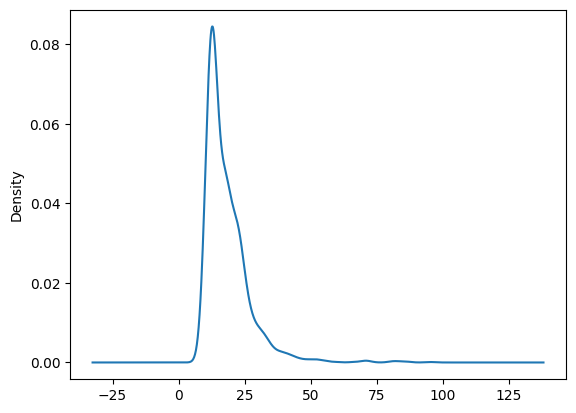

In [31]:
_ = by_order[by_order < 100].plot.kde()

* Box plot to see a distribution

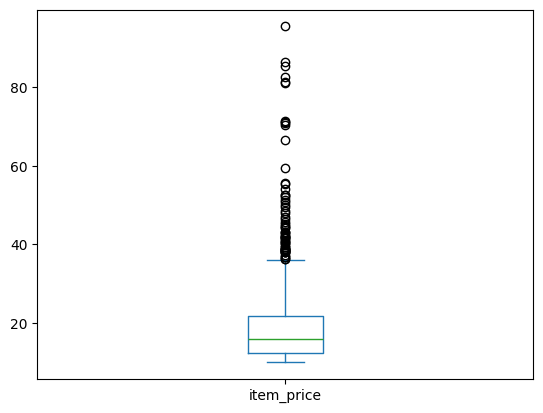

In [32]:
_ = by_order[by_order < 100].plot.box()

### Advanced Revenue Analysis

We split the orders based on their value. There is a category for orders between 0 and \\$10, then \\$10 to \\$20:
* 0-10, 10-20, 20-30, 30-40, 40-50, 50-100, 100+

We want to show 2 data:
* How many orders from each category, in relation to the total number of orders
* What is the total revenue per order category, in relation to the total revenue

We can show this with Pie Charts.

**Step 1**

* create a dataframe, from the `orders` data
* rename the unique column to a meaningful name
* see how the index is a number, but not a sequence from 0, and the index has a name `order_id`


In [33]:
orders = pd.DataFrame(by_order)   ## convert the Series to a single-column DataFrame
orders.columns = ['total_order']  ## change the column name from 'item_price' to 'total_order' (revenue per order)
orders.head()

,total_order
order_id,
1,11.56
2,16.98
3,12.67
4,21.00
5,13.70


In [34]:
## the original column name was 'item_price', why? 
orders_1 = pd.DataFrame(by_order) 
orders_1.head() 

,item_price
order_id,
1,11.56
2,16.98
3,12.67
4,21.00
5,13.70


* `pd.cut` is a function from the module `pd`
* it takes a list of values, `orders['total_order']` is the column `total_order`
* it takes also the limits of our categories, as the `bins=` argument
* and the names of these categories as `labels=` argument
* the `sample` method returns a random sample from the dataframe `orders`

In [43]:
orders['order_value'] = pd.cut(
    orders['total_order'],
    bins=[0, 10, 20, 30, 40, 50, 100, 10000],  ## 10000 is big enough as the maximum order value is 205.25
    labels=['0-10', '10-20', '20-30', '30-40', '40-50', '50-100', '100+'],
    include_lowest=True
)
orders.sample(5)  ## 5 random rows

,total_order,order_value
order_id,,
913,31.70,30-40
1285,17.50,10-20
649,41.80,40-50
802,10.98,10-20
829,12.95,10-20


In [36]:
orders.dtypes

total_order     float64
order_value    category
dtype: object

In [44]:
## sort the rows of a DataFrame according to the value of a column
orders = orders.sort_values(by='total_order', ascending=False)
orders.tail()

,total_order,order_value
order_id,,
1262,10.08,10-20
1436,10.08,10-20
889,10.08,10-20
14,10.08,10-20
17,10.08,10-20


* group by category, using the column `order_value`
* `count()` will only count the number of rows in each category

In [39]:
orders.groupby('order_value').count()  ## interval 0-10 has 0 case; it won't be show in the pie later on

C:\Users\orrru\AppData\Local\Temp\ipykernel_14648\3663647001.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders.groupby('order_value').count()  ## interval 0-10 has 0 case; it won't be show in the pie later on


,total_order
order_value,
0-10,0
10-20,1268
20-30,423
30-40,90
40-50,25
50-100,20
100+,8


In [ ]:
orders.groupby('order_value', observed=True).count()  ## 

,total_order
order_value,
10-20,1268
20-30,423
30-40,90
40-50,25
50-100,20
100+,8


* use `.plot.pie` method to draw a pie chart

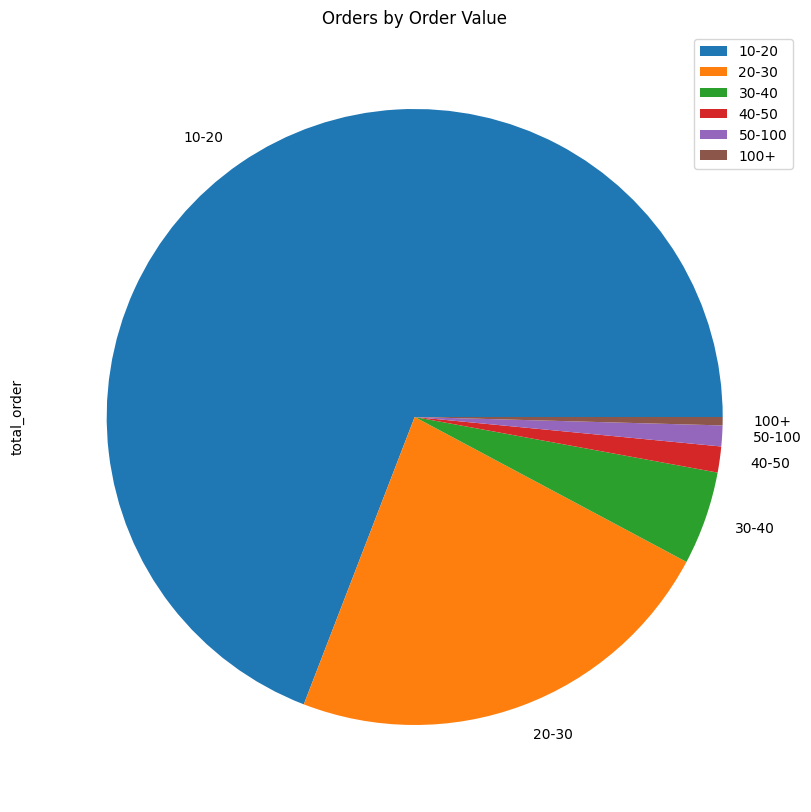

In [46]:
# How many orders from each order_value category, in relation to the total number of orders
_ = orders.groupby('order_value', observed=True).count().plot.pie(y='total_order', figsize=(10,10), title='Orders by Order Value')

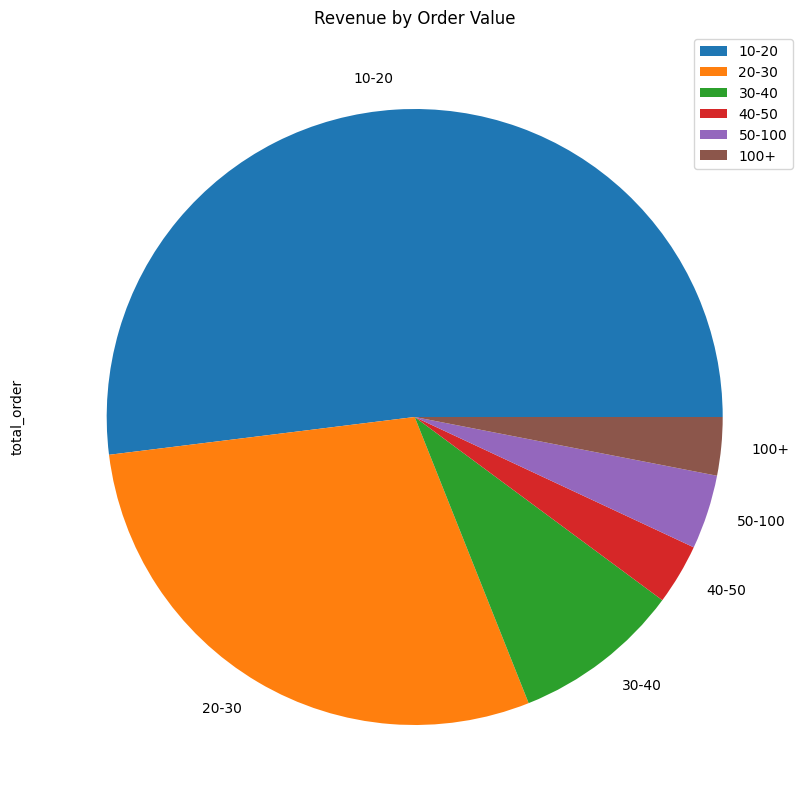

In [47]:
# What is the total revenue per order_value category, in relation to the total revenue
_ = orders.groupby('order_value', observed=True).sum().plot.pie(y='total_order', figsize=(10,10), title='Revenue by Order Value')